# NLP Lab 5 · Cleaning Dataset for Question Answering


In [1]:

!pip -q install datasets pandas pyarrow numpy

from datasets import load_dataset, DatasetDict
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os, re, unicodedata
from pathlib import Path

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1) Dataset loading


In [2]:

ds = load_dataset("tcabanski/mental_health_counseling_responses")
ds


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['questionTitle', 'questionText', 'answerText', 'therapistInfo', 'is_human', 'empathy', 'appropriateness', 'relevance', 'explanation', 'rater'],
        num_rows: 26140
    })
})

## 2) Null values

In [3]:
def remove_columns(ds):
    ds = ds.remove_columns(['therapistInfo', 'explanation', 'rater', 'appropriateness'])
    return ds

def fill_question_text_with_title(df):
    """
    Si 'questionText' es nulo o vacío, lo reemplaza por el valor de 'questionTitle'.
    Devuelve el DataFrame modificado.
    """
    df["questionText"] = df.apply(
        lambda row: row["questionTitle"] if pd.isna(row["questionText"]) or row["questionText"] == "" else row["questionText"],
        axis=1
    )
    return df.drop(columns=['questionTitle'])

def drop_null(df, name):
    """
    Elimina las filas donde 'answerText' sea None o una cadena vacía.
    Devuelve un nuevo DataFrame limpio.
    """
    df = df[~df[name].isna()]  # elimina None / NaN
    df = df[df[name].str.strip() != ""]  # elimina cadenas vacías
    return df.reset_index(drop=True)


train = ds['train']

train = remove_columns(train)
train = train.to_pandas()

print(train.isnull().sum())

train = fill_question_text_with_title(train)
train = drop_null(train, 'answerText')

print(train.isnull().sum())

questionTitle       0
questionText     1756
answerText        104
is_human            0
empathy             0
relevance           0
dtype: int64
questionText    0
answerText      0
is_human        0
empathy         0
relevance       0
dtype: int64


## 3) Cleaning helpers

In [4]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_TAG_RE = re.compile(r"<.*?>")

def basic_clean(text: str) -> str:
    if not isinstance(text, str): return ""
    t = text.strip()
    t = re.sub(URL_RE, " ", t)
    t = re.sub(HTML_TAG_RE, " ", t)
    t = unicodedata.normalize("NFKC", t)
    t = re.sub(r"\s+", " ", t)
    return t

def normalize_df(df: pd.DataFrame) -> pd.DataFrame:
    df["questionText"] = df["questionText"].astype(str).apply(basic_clean)
    df["answerText"] = df["answerText"].astype(str).apply(basic_clean)
    return df

clean_train_df = normalize_df(train)
clean_train_df.head(2)

,questionText,answerText,is_human,empathy,relevance
0,I'm feeling different towards my husband. I fe...,It's completely normal to experience a shift i...,False,5,5
1,"He said that if I were to visit my mother, he ...",It sounds like you're feeling a bit concerned ...,False,4,4


## 4) Lenght statistics


In [5]:
def text_lengths(s: pd.Series):
    return s.astype(str).apply(lambda x: len(x.split())).tolist()

q_lens = text_lengths(clean_train_df["questionText"])
ans_lens = text_lengths(clean_train_df["answerText"])

print("Avg question len (tokens):", np.mean(q_lens))
print("Avg answer len (tokens):", np.mean(ans_lens))

Avg question len (tokens): 55.17806114610539
Avg answer len (tokens): 296.09310185896453


## 5) Plots: lengths & duplicates


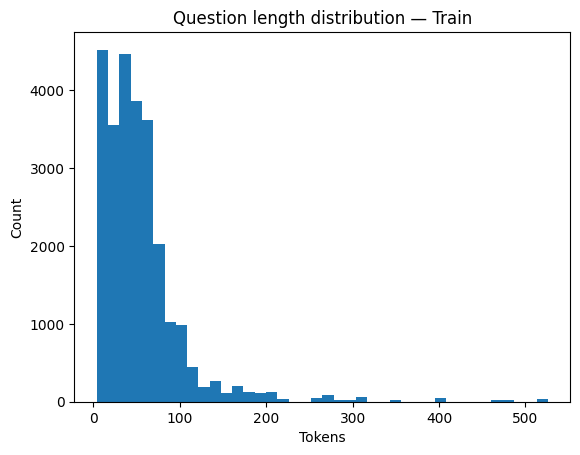

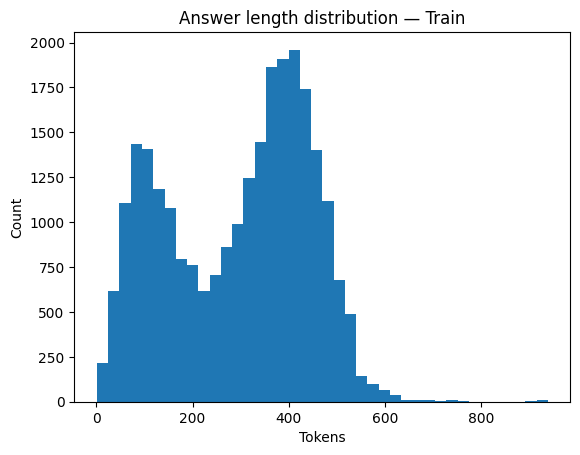

Duplicate question + answer rows: 19527


In [6]:
def plot_hist(values, title, xlabel):
    plt.figure()
    plt.hist(values, bins=40)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

plot_hist(q_lens, "Question length distribution — Train", "Tokens")
plot_hist(ans_lens, "Answer length distribution — Train", "Tokens")

dup_rows = clean_train_df.duplicated(subset=["questionText","answerText"]).sum()
print("Duplicate question + answer rows:", dup_rows)


## 6) Train/Val/Test split (holdout from train)

In [7]:
from sklearn.model_selection import train_test_split

X = clean_train_df.copy()
# For reproducibility, create val/test 15% each from train
X_train, X_temp = train_test_split(X, test_size=0.3, random_state=RANDOM_SEED)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=RANDOM_SEED)

print("Sizes:", len(X_train), len(X_val), len(X_test))
X_train.head(2)


Sizes: 18225 3905 3906


,questionText,answerText,is_human,empathy,relevance
10801,Do I have to go to counseling to get hormones ...,Hello! You've gotten some great answers here! ...,True,5,5
22829,How can I control my anxiety when I have Obses...,Hello! It's great that you're looking to manag...,False,4,5


## 7) Save cleaned splits

In [8]:
outdir = "qa_cleaned_splits"
os.makedirs(outdir, exist_ok=True)
X_train.to_json(os.path.join(outdir, "train.jsonl"), orient="records", lines=True, force_ascii=False)
X_val.to_json(os.path.join(outdir, "val.jsonl"), orient="records", lines=True, force_ascii=False)
X_test.to_json(os.path.join(outdir, "test.jsonl"), orient="records", lines=True, force_ascii=False)
print("Saved to", outdir)

Saved to qa_cleaned_splits
